In [1]:
### LIBRARIES ###
library(Seurat)
library(ggridges)
library(H5weaver)
library(ggplot2)
library(magrittr)
library(data.table)
library(dplyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.2”
Loading required package: Matrix

Warning message:
“package ‘Matrix’ was built under R version 4.4.2”
Loading required package: rhdf5

Warning message:
“package ‘rhdf5’ was built under R version 4.4.2”

Attaching package: ‘H5weaver’


The following objects are masked from ‘package:rhdf5’:

    h5dump, h5ls



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
updated_read_h5_seurat <- function(h5_file,
                           target = "matrix",
                           feature_names = "name",
                           ...) {

  if(!requireNamespace("Seurat", versionCheck = list(op = ">=", version = "3.1.0"))) {
    stop("Can't find the Seurat package. Please install with install.packages(\"Seurat\")")
  }

  assertthat::assert_that(is.character(h5_file))
  assertthat::assert_that(length(h5_file) == 1)
  assertthat::assert_that(typeof(feature_names) == "character")
  assertthat::assert_that(length(feature_names) == 1)
  assertthat::assert_that(feature_names %in% c("id","name"))

  mat <- read_h5_dgCMatrix(h5_file,
                           target = target,
                           feature_names = feature_names)

  cell_meta <- read_h5_cell_meta(h5_file,
                                 target = target)
  rownames(cell_meta) <- cell_meta$barcodes

  rownames(cell_meta) <- cell_meta$barcodes
  feat_meta <- read_h5_feature_meta(h5_file,
                                    target = target)
  rownames(feat_meta) <- make.unique(feat_meta[[feature_names]])

  cite_10x <- FALSE
  cite_injected <- FALSE

  # Check for cellranger CITE-seq data
  if("feature_type" %in% names(feat_meta)) {
    if("Antibody Capture" %in% feat_meta$feature_type) {
      cite_10x <- TRUE
    }
  }

  if(cite_10x) {
    cite_feat <- feat_meta[feat_meta$feature_type == "Antibody Capture",]
    feat_meta <- feat_meta[feat_meta$feature_type != "Antibody Capture",]

    cite_mat <- mat[cite_feat$id,]
    mat <- mat[feat_meta$id,]
  }
    
  # Check for injected CITE-seq data
  if("ADT" %in% h5ls(h5_file)$name) {
    cite_injected <- TRUE
  }

  if(cite_injected) {
    cite_mat <- read_h5_dgCMatrix(h5_file, "ADT", feature_names = "id")
    colnames(cite_mat) <- cell_meta$barcodes
    cite_feat <- read_h5_feature_meta(h5_file, target = "ADT")
    rownames(cite_feat) <- make.unique(cite_feat[["id"]])
  }
  unique_rownames <- make.unique(rownames(mat))
  rownames(mat) <- unique_rownames
  so <- Seurat::CreateSeuratObject(counts = mat,
                                   meta.data = cell_meta,
                                   ...)
  so[["RNA"]] <- Seurat::AddMetaData( so[["RNA"]], feat_meta)
      
  if(cite_10x|cite_injected) {
    so[["ADT"]] <- Seurat::CreateAssayObject(counts = cite_mat)
    so[["ADT"]] <- Seurat::AddMetaData( so[["ADT"]], cite_feat)
  }

  so
}

In [2]:
h5_input <- list.files(path = 'prime3_lauren_align/', pattern = '.h5', full.names = TRUE, recursive = TRUE)
h5_input

[1] "prime3_lauren_align//B007-P2_PB00257-01_2020-06-25T12:38:29.677205289Z_labeled.h5"
[2] "prime3_lauren_align//B026-P1_PB00287-01_2020-10-10T20:09:23.161979427Z_labeled.h5"
[3] "prime3_lauren_align//B072-P1_PB01565-01_2021-07-12T17:24:36.579193615Z_labeled.h5"
[4] "prime3_lauren_align//B075-P1_PB01606-01_2021-07-19T01:12:47.537590436Z_labeled.h5"

In [6]:
so_list <- lapply(h5_input, updated_read_h5_seurat)

In [7]:
so <- Reduce(merge, so_list)

In [8]:
so

An object of class Seurat 
33538 features across 81812 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)
 4 layers present: counts.1.1.1, counts.2, counts.2.1, counts.2.1.1

In [9]:
so <- JoinLayers(so)

In [10]:
table(so$AIFI_PBMC_L1)


         B cell              DC     Erythrocyte             ILC        Monocyte 
           6670             968              53              25           15587 
        NK cell        Platelet Progenitor cell          T cell 
           7182             386              79           50862 

In [17]:
isotype_meta <- read.csv('lauren_isotype_files/adata-all-b_isotypes_cutoff0.5.csv')
rownames(isotype_meta) <- isotype_meta$barcodes
head(isotype_meta)

,barcodes,original_barcodes,cell_name,batch_id,pool_id,chip_id,well_id,n_genes,n_reads,n_umis,⋯,IGHG4_pos,IGHA1_pos,IGHA2_pos,IGHE_pos,IGHM_pos,IGHD_pos,n_pos,concat_pos,switched_status,isotype
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
f1e86c2ab60011eab67ebe566d2ea52c,f1e86c2ab60011eab67ebe566d2ea52c,ATTTCTGCAATTGAAG,briny_maximum_abalone,B007,B007-P2,B007-P2C2,B007-P2C2W6,1919,16929,6141,⋯,False,False,False,False,True,True,2,IGHM;IGHD,nonswitched,IGHM;IGHD
da51f710b5ac11eab4e3162edf74bcf8,da51f710b5ac11eab4e3162edf74bcf8,TGTAACGAGTCACTAC,lopsided_resentful_bedbug,B007,B007-P2,B007-P2C2,B007-P2C2W8,1388,13120,4653,⋯,False,False,False,False,True,True,3,IGHG3;IGHM;IGHD,nonswitched,IGHM;IGHD
cb604e1ab5b511eaa4e2f6fba77396ac,cb604e1ab5b511eaa4e2f6fba77396ac,TCGATTTCATCGGAGA,honorific_spineless_vampirebat,B007,B007-P2,B007-P2C3,B007-P2C3W1,1592,15072,5497,⋯,False,True,False,False,True,True,4,IGHG3;IGHA1;IGHM;IGHD,nonswitched,IGHM;IGHD
cb6bebb2b5b511eaa4e2f6fba77396ac,cb6bebb2b5b511eaa4e2f6fba77396ac,TTTGATCAGATCCTAC,floury_byzantium_fly,B007,B007-P2,B007-P2C3,B007-P2C3W1,1549,12842,4749,⋯,False,False,False,False,True,True,3,IGHG2;IGHM;IGHD,nonswitched,IGHM;IGHD
07b56e62b5a311eaa648b6277b8949f6,07b56e62b5a311eaa648b6277b8949f6,TTAGGGTGTGTATTGC,impending_broad_coati,B007,B007-P2,B007-P2C3,B007-P2C3W2,1395,12924,4562,⋯,False,False,False,False,True,False,2,IGHG3;IGHM,nonswitched,IGHM
23763f02b5a111eaa22f56104356552a,23763f02b5a111eaa22f56104356552a,ATTATCCAGCCTGTCG,taxidermy_delayable_gourami,B007,B007-P2,B007-P2C3,B007-P2C3W3,1108,9315,3063,⋯,False,False,False,False,True,True,4,IGHG1;IGHG3;IGHM;IGHD,nonswitched,IGHM;IGHD


In [12]:
table(isotype_meta$barcodes %in% rownames(so@meta.data))


TRUE 
5870 

In [13]:
iso_subset <- subset(so, cells = isotype_meta$barcodes)
iso_subset

An object of class Seurat 
33538 features across 5870 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)
 1 layer present: counts

In [15]:
table(iso_subset$AIFI_PBMC_L1)
table(iso_subset$AIFI_PBMC_L3)


B cell 
  5870 


       Activated memory B cell          CD27+ effector B cell 
                             9                            321 
         CD27- effector B cell             CD95 memory B cell 
                           173                             62 
            Core memory B cell              Core naive B cell 
                          1744                           3091 
           Early memory B cell              ISG+ naive B cell 
                            46                            101 
                   Plasma cell            Transitional B cell 
                            52                            185 
Type 2 polarized memory B cell 
                            86 

In [18]:
iso_subset <- AddMetaData(iso_subset, metadata = isotype_meta, col.name = 'isotype')

In [19]:
iso_subset <- AddMetaData(iso_subset, metadata = isotype_meta, col.name = 'switched_status')

## Sanity Check

In [21]:
test <- subset(iso_subset, AIFI_PBMC_L3 == 'Activated memory B cell')

In [23]:
test$isotype

e51950000f5f11ebb40cfec00d040e61 b27d5a7e0f6411eba11076fca6527e4e 
                     "IGHM;IGHD"                      "IGHM;IGHD" 
4538c3a20f5711eb885b7212389c42d3 a1274d5ae3ff11eb93500659192c98a0 
                     "IGHM;IGHD"                   "undetermined" 
0c984584e3fc11ebb856263d612e98a2 38c18238e9c911ebaefdb24e308fca41 
                         "IGHA1"                          "IGHG2" 
095b2504e91411eb8bcd26b8855f296c 255cb1d0e91111eba23be6800fbef097 
                     "IGHM;IGHD"                           "IGHM" 
420e4462e8fb11eb8601f2173f6f311c 
                          "IGHM"

In [29]:
test2 <- subset(isotype_meta, barcodes %in% test$barcodes)

In [31]:
select(test2, barcodes, isotype)

,barcodes,isotype
,<chr>,<chr>
38c18238e9c911ebaefdb24e308fca41,38c18238e9c911ebaefdb24e308fca41,IGHG2
095b2504e91411eb8bcd26b8855f296c,095b2504e91411eb8bcd26b8855f296c,IGHM;IGHD
255cb1d0e91111eba23be6800fbef097,255cb1d0e91111eba23be6800fbef097,IGHM
420e4462e8fb11eb8601f2173f6f311c,420e4462e8fb11eb8601f2173f6f311c,IGHM
e51950000f5f11ebb40cfec00d040e61,e51950000f5f11ebb40cfec00d040e61,IGHM;IGHD
b27d5a7e0f6411eba11076fca6527e4e,b27d5a7e0f6411eba11076fca6527e4e,IGHM;IGHD
4538c3a20f5711eb885b7212389c42d3,4538c3a20f5711eb885b7212389c42d3,IGHM;IGHD
a1274d5ae3ff11eb93500659192c98a0,a1274d5ae3ff11eb93500659192c98a0,undetermined
0c984584e3fc11ebb856263d612e98a2,0c984584e3fc11ebb856263d612e98a2,IGHA1


# Normalize and Visualize

In [32]:
iso_subset <- NormalizeData(iso_subset)

Normalizing layer: counts



In [33]:
table(iso_subset$switched_status)


 nonswitched     switched undetermined 
        5181          667           22 

In [34]:
unswitched_subset <- subset(iso_subset, switched_status == 'nonswitched')

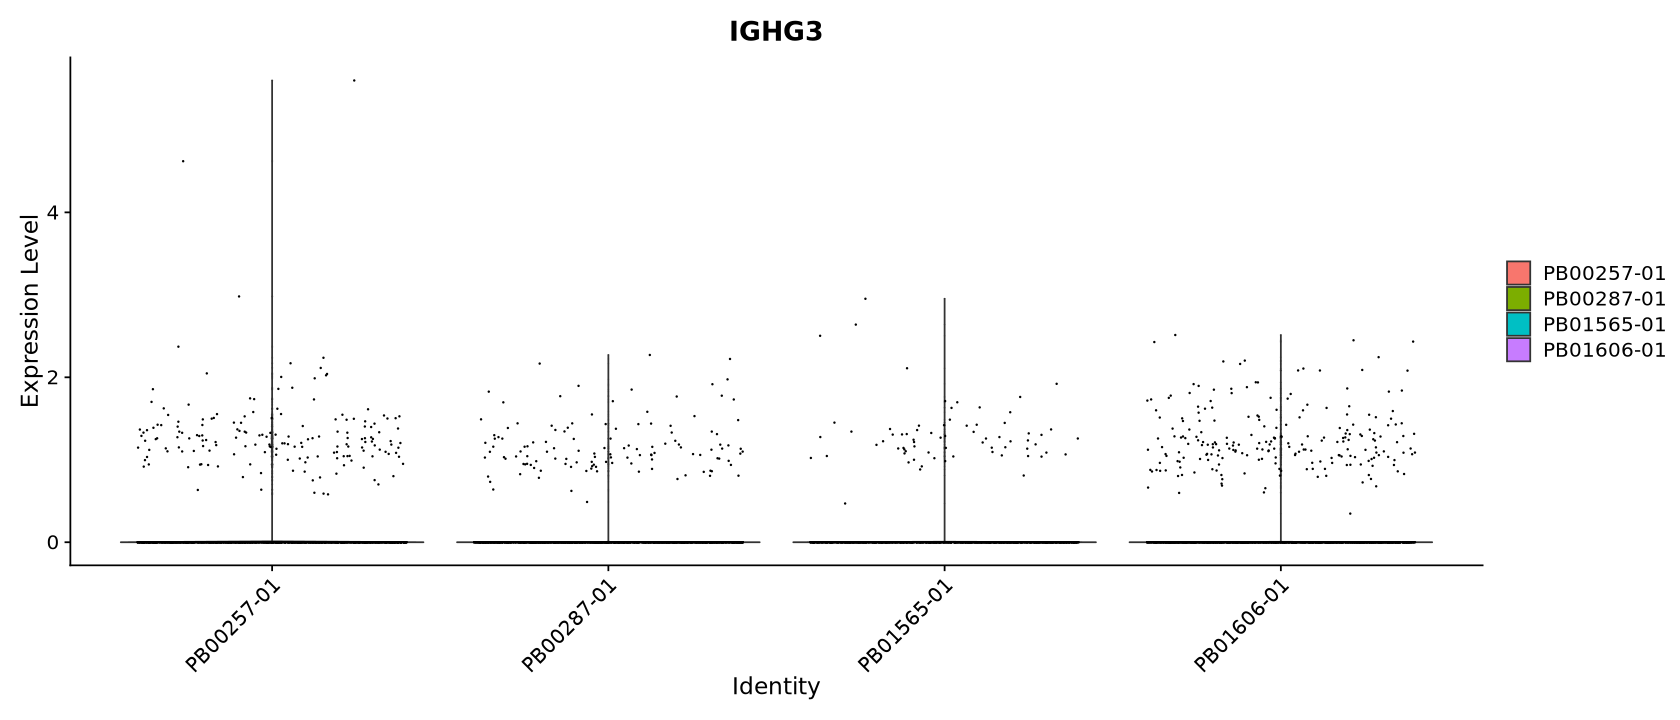

In [35]:
options(repr.plot.width = 14, repr.plot.height = 6)
VlnPlot(unswitched_subset, features = 'IGHG3', group.by = 'pbmc_sample_id')

In [36]:
core_naive_unswitched_subset <- subset(unswitched_subset, AIFI_PBMC_L3 == 'Core naive B cell')

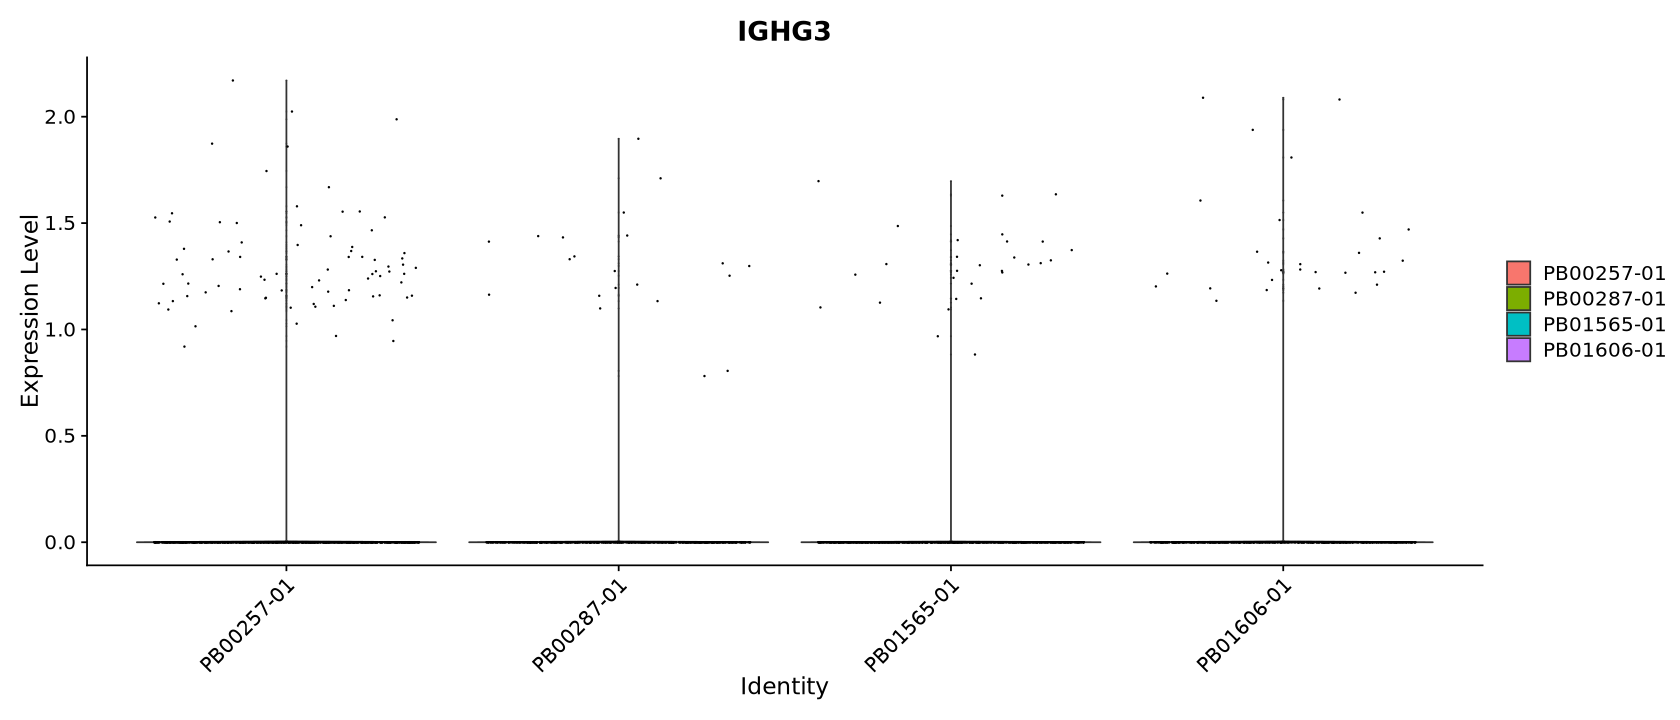

In [37]:
options(repr.plot.width = 14, repr.plot.height = 6)
VlnPlot(core_naive_unswitched_subset, features = 'IGHG3', group.by = 'pbmc_sample_id')

In [38]:
ighg3_pos <- subset(unswitched_subset, IGHG3 > 0)
ighg3_pos

An object of class Seurat 
33538 features across 599 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)
 2 layers present: counts, data

In [39]:
unswitched_subset

An object of class Seurat 
33538 features across 5181 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)
 2 layers present: counts, data

In [40]:
599 / 5181

[1] 0.1156147

# Save Object

In [41]:
saveRDS(iso_subset, 'prime3_iso_subset.rds')

In [42]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] dplyr_1.1.4        magrittr_2.0.3     ggplot2_3.5.1      H5weaver_1.3.0    
 [5] rhdf5_2.50.0       Matrix_1.7-2       data.table_1.16.4  ggridges_0.5.6    
 [9] Seurat_5.2.1       SeuratObject_5.0.2 sp_2.1-4          

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-2          g